# Báo cáo Phần 2 - Cấu trúc doanh thu: Tiền thật sự đi đâu?
**Datathon 2026 - The Gridbreakers - VinTelligence**

## Insight

> Biên lợi nhuận giảm từ **17.6% (2012)** xuống **5.4% (2022)** không phải do COVID tạo ra — mà do cơ chế promo âm GP tích lũy từ trước đại dịch. **36/36 promo Pre-COVID (2012–2019)** đều âm contribution: đây là lỗi cấu trúc, không phải cú sốc nhất thời.
>
> COVID (2020–2021) là ngoại lệ hợp lý: nền kinh tế suy yếu, người tiêu dùng ưu tiên hàng giá rẻ, doanh nghiệp cần giữ chân khách để tồn tại. **10/10 promo COVID âm GP** — nhưng trong bối cảnh khủng hoảng, chi phí giữ chân có thể chấp nhận được, không phải lỗi thiết kế thuần túy.
>
> Đại dịch đã kết thúc. **Post-COVID (2022), 4/4 promo vẫn âm GP** mà không còn lý do ngoại lệ. Kết luận: **cắt và điều chỉnh promo ngay bây giờ để phục hồi biên lợi nhuận**.

*Phân tích dùng contribution accounting + counterfactual proxy — chưa phải causal experiment. Khuyến nghị thận trọng: pause/reprice/redesign các mẫu promo âm; không mở rộng trong giai đoạn bình thường.*

## Chuỗi bằng chứng

```text
Doanh thu tăng → margin suy giảm từ trước COVID [Act 1]
  → promo âm GP xuyên suốt Pre-COVID, COVID, Post-COVID [Act 2]
  → pause/redesign cải thiện GP ngay cả khi chỉ dùng dữ liệu 2022 [Act 3]
  → stockout overlap là rủi ro vận hành mang tính cấu trúc [Act 4]
  → không lặp lại 50 mẫu promo cũ; thiết kế lại cổng duyệt [Act 5]
```

| Act | Câu hỏi trung tâm | Số liệu chính |
|-----|-------------------|---------------|
| 1 | Margin xấu đi từ bao giờ? | Pre-COVID 6.7%, COVID 5.3%, Post-COVID 5.4% |
| 2 | Promo âm là cấu trúc hay artifact COVID? | Pre 36/36; COVID 10/10; Post 4/4 — đều âm |
| 3 | Cắt promo âm có bền không? | Full history GP +84.3%; 2022-only GP +90.0% |
| 4 | Stockout có spike trong COVID? | Pre 67.5%, COVID 67.1%, Post 66.7% — ổn định |
| 5 | Hành động cụ thể? | Pause 50 mẫu cũ; redesign cổng duyệt promo |


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"

PERIOD_LABELS = {
    "Pre-COVID": "Pre-COVID (2012-2019)",
    "COVID": "COVID (2020-2021)",
    "Post-COVID": "Post-COVID (2022)",
}

# Act 1 - Bề mặt vs. thực tế

**Câu hỏi trung tâm:** Doanh thu tăng, nhưng bao nhiêu phần doanh thu thật sự còn lại sau chiết khấu, hoàn tiền, phí vận chuyển và giá vốn?

Phân tích bắt đầu từ cấu trúc doanh thu để tách phần bị bào mòn khỏi phần lợi nhuận còn giữ lại.


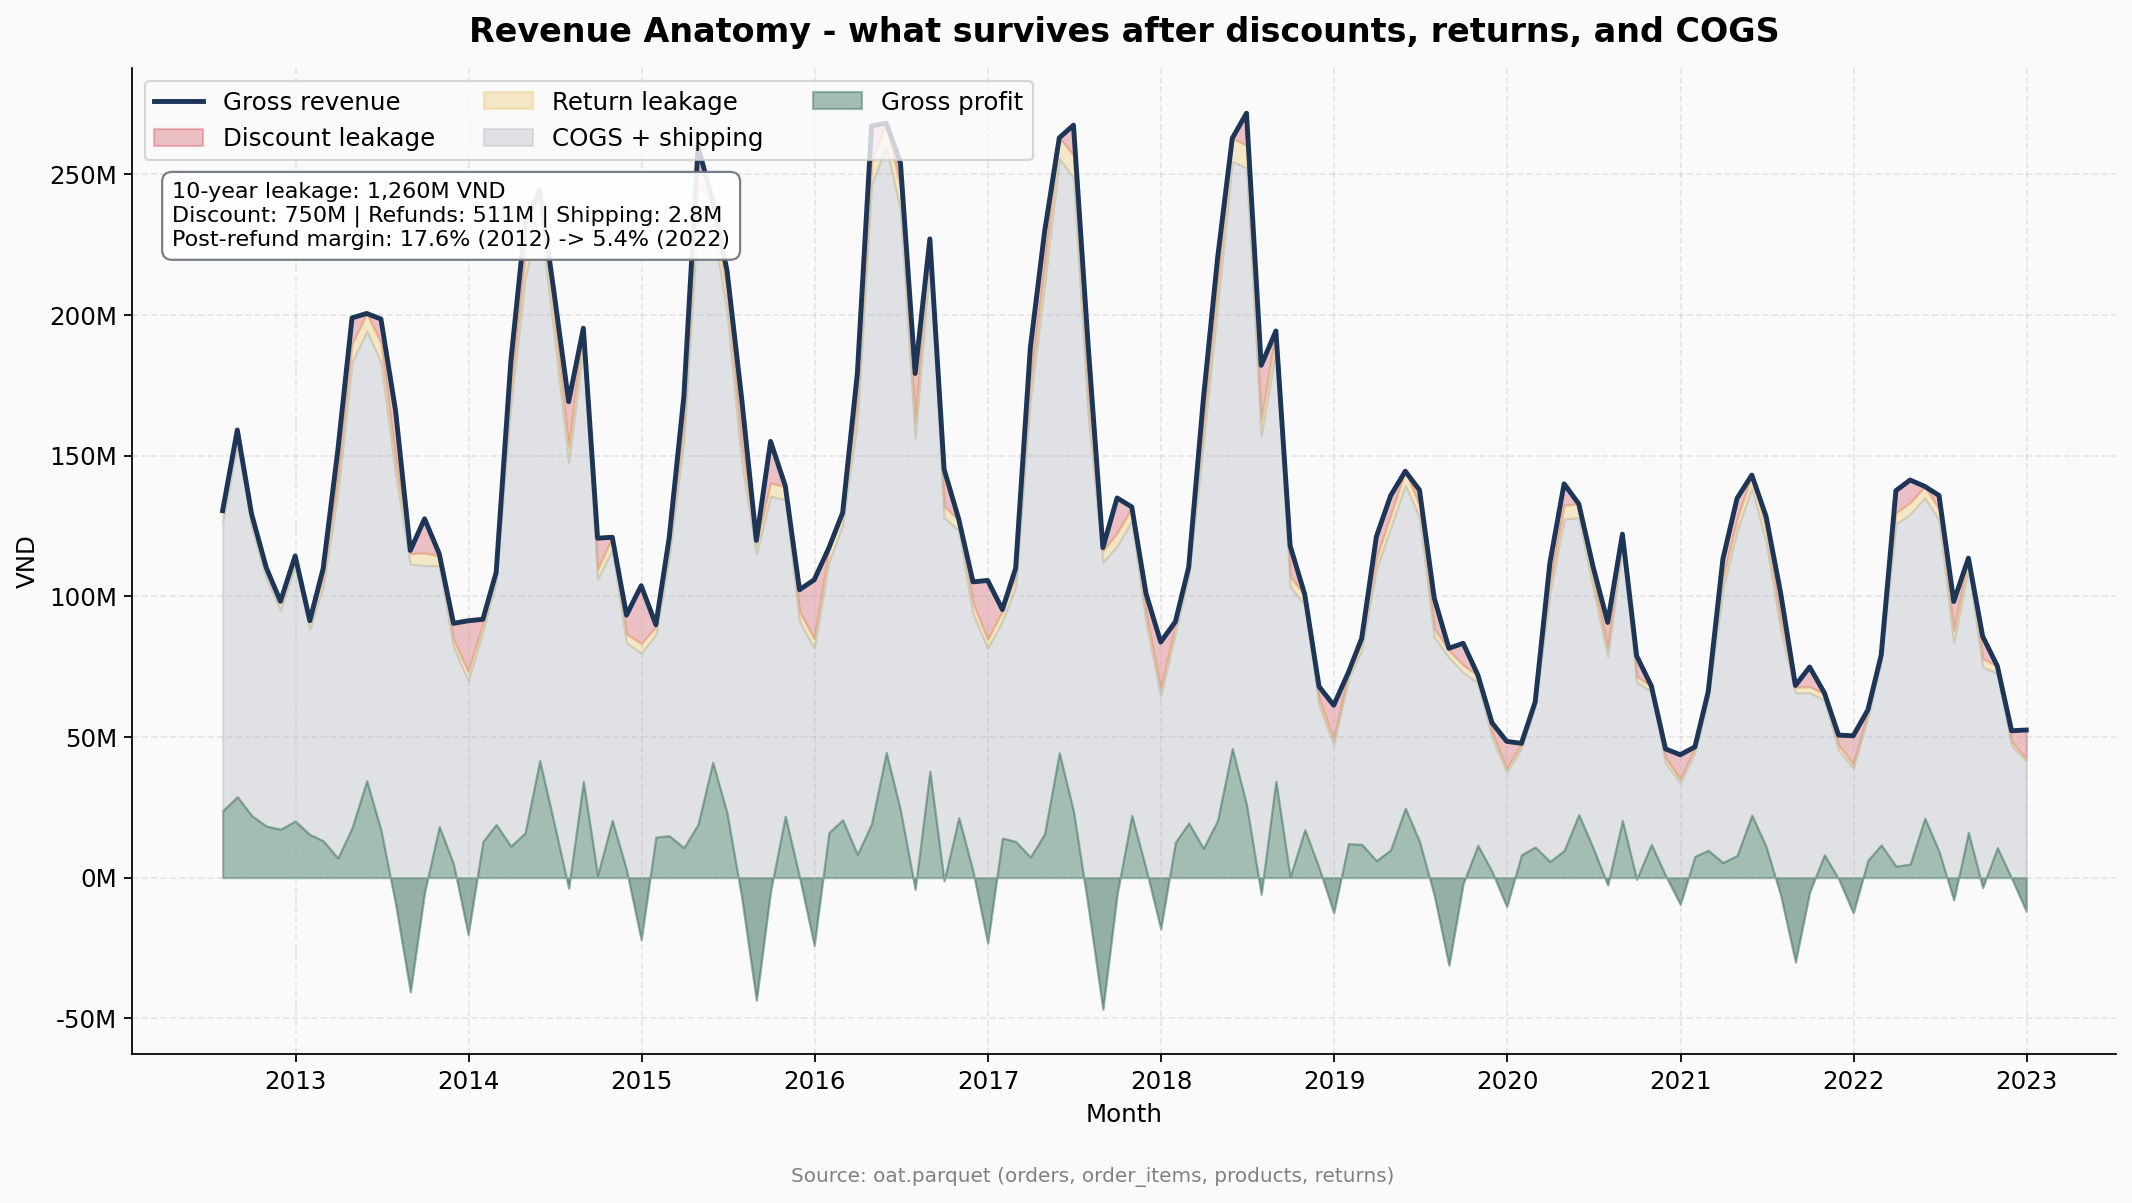

In [2]:
display(Image(str(CHARTS / "chart1_revenue_anatomy.png"), width=950))


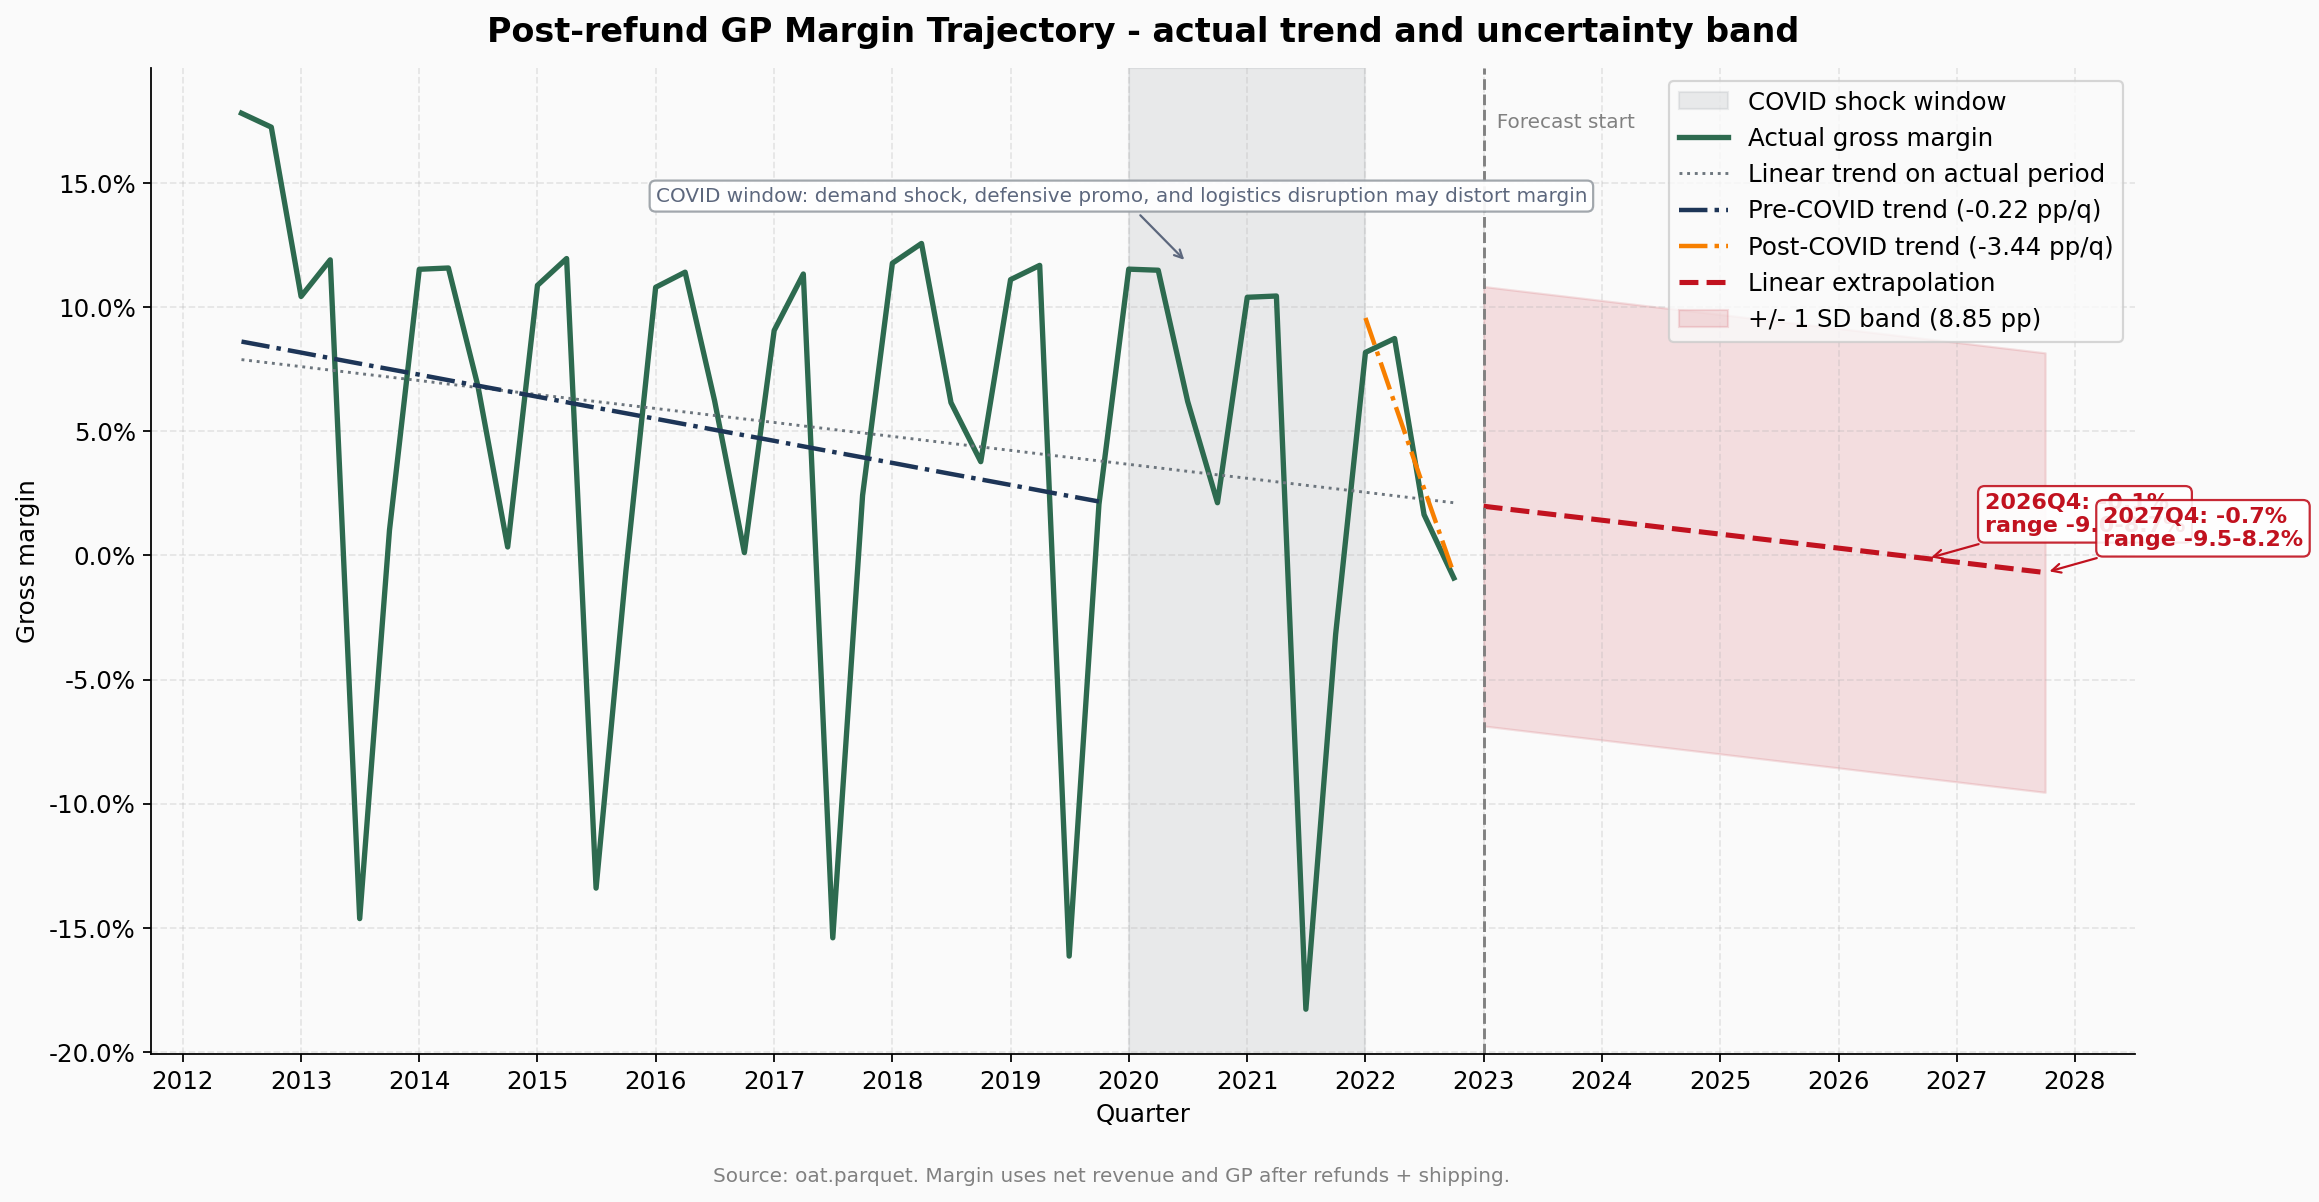

In [3]:
display(Image(str(CHARTS / "chart5_margin_trajectory.png"), width=950))

In [4]:
category = pd.read_csv(TABLES / "category_double_loss_table.csv")
category_display = category.rename(columns={
    "category": "nganh_hang",
    "discount_rate": "ty_le_chiet_khau",
    "return_rate": "ty_le_tra_hang",
    "gross_revenue": "doanh_thu_gop",
    "rows": "so_dong",
    "quadrant": "nhom",
})
display(category_display)

status = pd.read_csv(TABLES / "order_status_profit_audit.csv")
status_display = status.rename(columns={
    "order_status": "trang_thai_don",
    "rows": "so_dong",
    "orders": "so_don",
    "net_revenue": "doanh_thu_thuan",
    "gp_after_refund_shipping": "gp_sau_hoan_tien_va_ship",
    "gross_revenue": "doanh_thu_gop",
    "net_revenue_share": "ty_trong_doanh_thu_thuan",
    "gp_share": "ty_trong_gp",
})
display(status_display)


,nganh_hang,ty_le_chiet_khau,ty_le_tra_hang,doanh_thu_gop,so_dong,nhom
0,Casual,0.049890,0.053937,4.606484e+08,23991,Mixed
1,GenZ,0.049249,0.057214,3.435991e+08,37159,Mixed
2,Outdoor,0.067613,0.056618,2.494883e+09,259986,Double loss
3,Streetwear,0.048063,0.055393,1.313135e+10,393533,Healthy


,trang_thai_don,so_dong,so_don,doanh_thu_thuan,gp_sau_hoan_tien_va_ship,doanh_thu_gop,ty_trong_doanh_thu_thuan,ty_trong_gp
0,delivered,570887,516716,1.251818e+10,1.211201e+09,1.311709e+10,0.798309,1.206362
1,cancelled,65673,59462,1.447014e+09,1.396764e+08,1.515891e+09,0.092279,0.139118
2,returned,40034,36142,8.659387e+08,-4.273861e+08,9.075430e+08,0.055223,-0.425679
3,shipped,15094,13773,3.372788e+08,3.199425e+07,3.533760e+08,0.021509,0.031866
4,paid,14987,13577,3.306271e+08,3.196107e+07,3.459229e+08,0.021085,0.031833
5,created,7994,7275,1.818350e+08,1.656447e+07,1.906523e+08,0.011596,0.016498


In [5]:
period_margin = pd.read_csv(TABLES / "covid_period_margin_table.csv")
period_margin_display = period_margin.assign(
    period=period_margin["period"].replace(PERIOD_LABELS),
    gross_margin=period_margin["gross_margin"].map(lambda x: f"{x:.1%}"),
    discount_rate_on_net_revenue=period_margin["discount_rate_on_net_revenue"].map(lambda x: f"{x:.1%}"),
).rename(columns={
    "period": "giai_doan",
    "net_revenue": "doanh_thu_thuan",
    "gp_contribution": "dong_gop_loi_nhuan_gop",
    "discount_amount": "chiet_khau",
    "gross_margin": "bien_loi_nhuan_gop",
    "discount_rate_on_net_revenue": "ty_le_chiet_khau_tren_doanh_thu_thuan",
    "rows": "so_dong",
})
display(period_margin_display)

,giai_doan,doanh_thu_thuan,dong_gop_loi_nhuan_gop,chiet_khau,so_dong,bien_loi_nhuan_gop,ty_le_chiet_khau_tren_doanh_thu_thuan
0,Pre-COVID (2012-2019),1.256824e+10,8.388666e+08,5.949363e+08,602614,6.7%,4.7%
1,COVID (2020-2021),1.997323e+09,1.049981e+08,1.002293e+08,73987,5.3%,5.0%
2,Post-COVID (2022),1.115307e+09,6.014628e+07,5.444174e+07,38068,5.4%,4.9%


## Phân tích

10 năm: **749.6M VND** chiết khấu + **510.6M VND** hoàn tiền = **7.7% doanh thu gộp** trước khi xét giá vốn. Biên lợi nhuận giảm từ **17.6% (2012)** xuống **5.4% (2022)**.

Tách giai đoạn: **6.7% Pre-COVID → 5.3% COVID → 5.4% Post-COVID**. Mức 2022 nhỉnh hơn đỉnh COVID chỉ 0.1pp — phục hồi chưa diễn ra; baseline đã mỏng từ trước đại dịch.

Theo ngành hàng (4 điểm dữ liệu, đọc như bản đồ ưu tiên): **Outdoor** có cả tỷ lệ chiết khấu lẫn trả hàng trên trung vị. **Streetwear** quy mô lớn nhất (393K dòng) — tác động tài chính cao nhất.

**Kết luận Act 1:** Suy giảm margin là xu hướng Pre-COVID, không phải COVID shock. Promo là cơ chế cần kiểm tra ở Act 2.


# Act 2 - Ai đang làm rò rỉ biên lợi nhuận?

**Câu hỏi trung tâm:** Khuyến mãi có thật sự kéo về khách hàng tốt, hay chỉ tạo sản lượng rẻ với hiệu quả kinh tế kém? COVID có thể lý giải cho promo âm không, hay đây là lỗi thiết kế thuần túy?

Trọng tâm là kiểm tra hiệu quả từng chương trình khuyến mãi và chất lượng nhóm khách hàng đi kèm. Hành vi trả hàng là kiểm định phụ; bằng chứng chính nằm ở tỷ lệ mua lại và lợi nhuận gộp trên mỗi khách hàng.


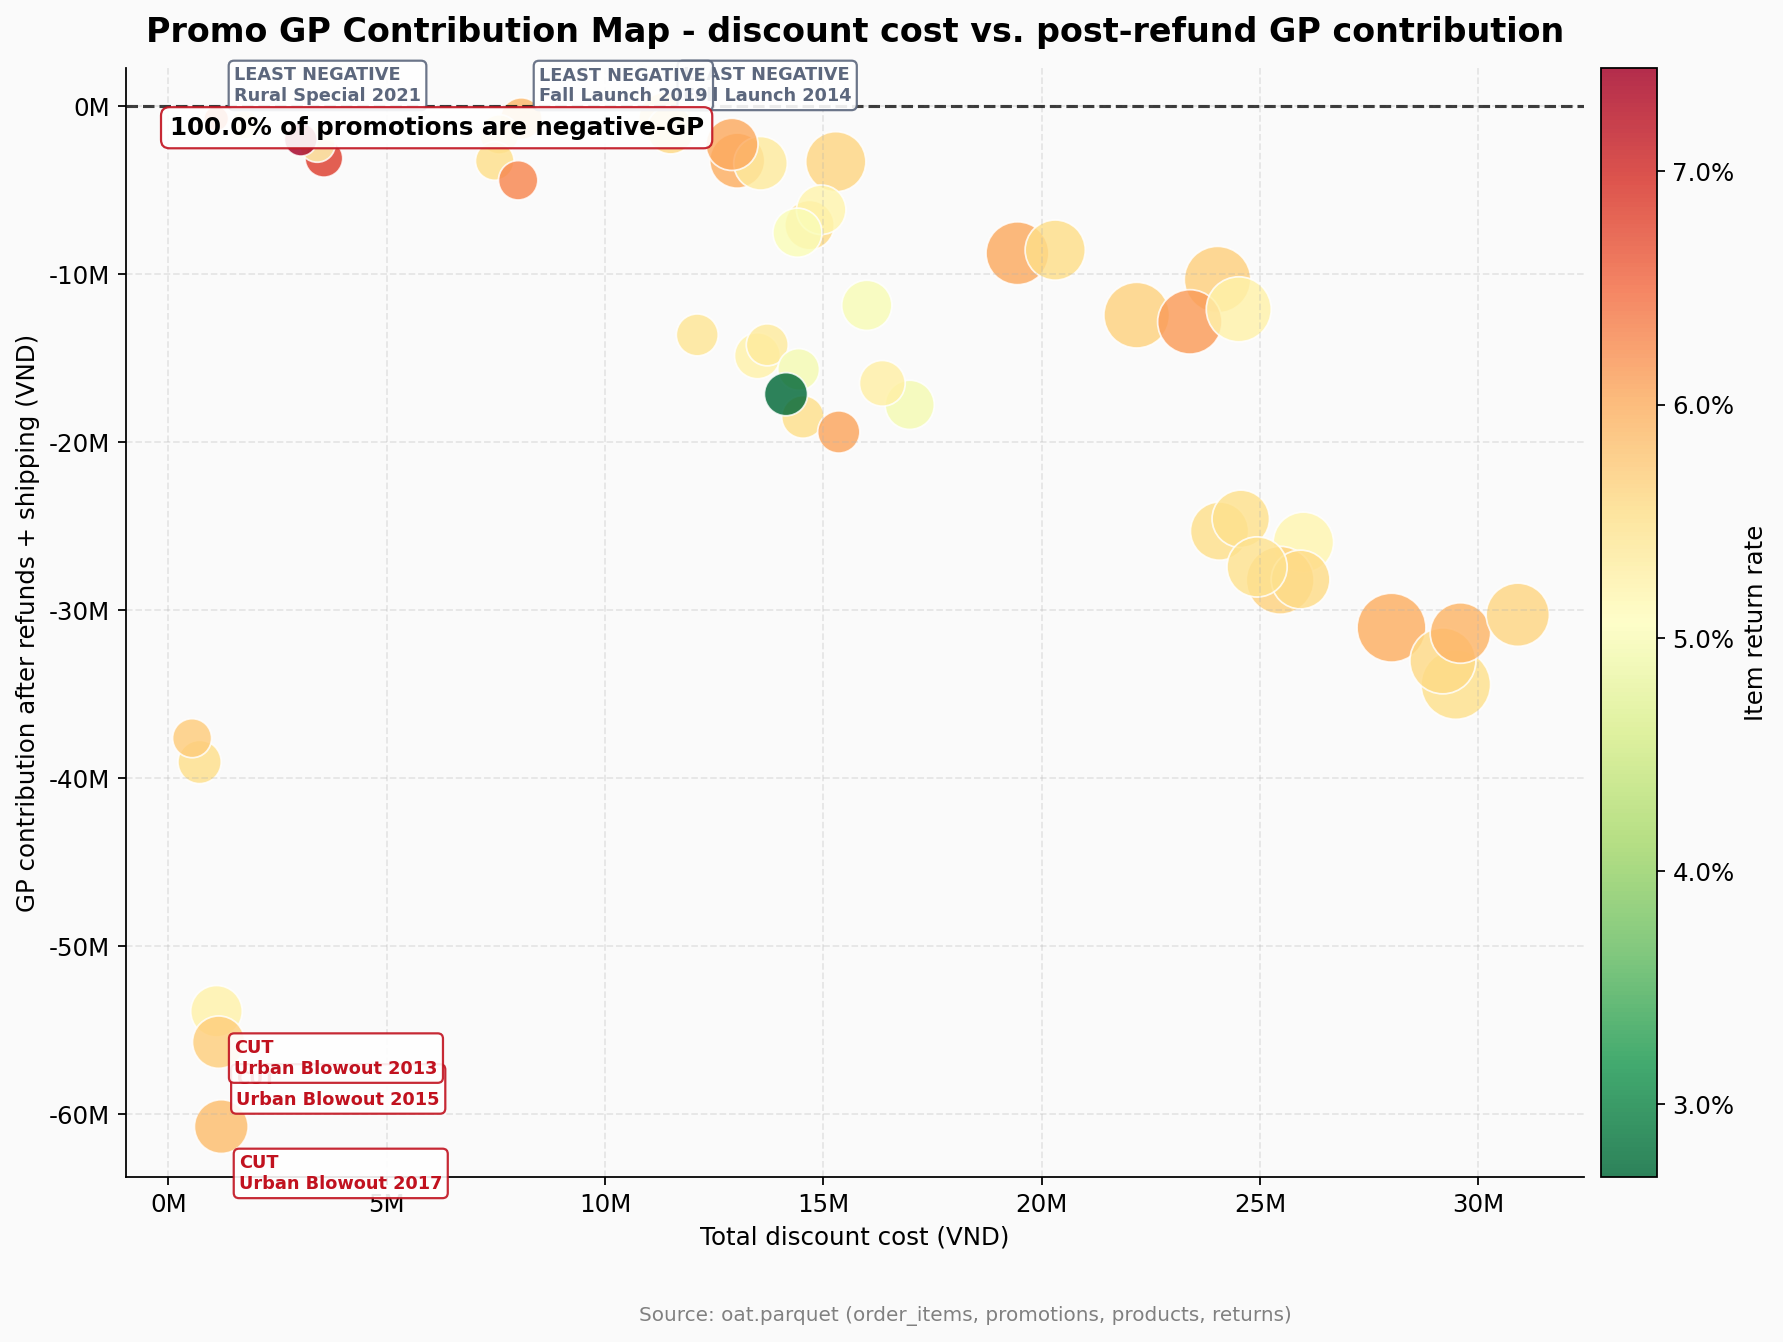

In [6]:
display(Image(str(CHARTS / "chart3_promo_roi_scatter.png"), width=950))


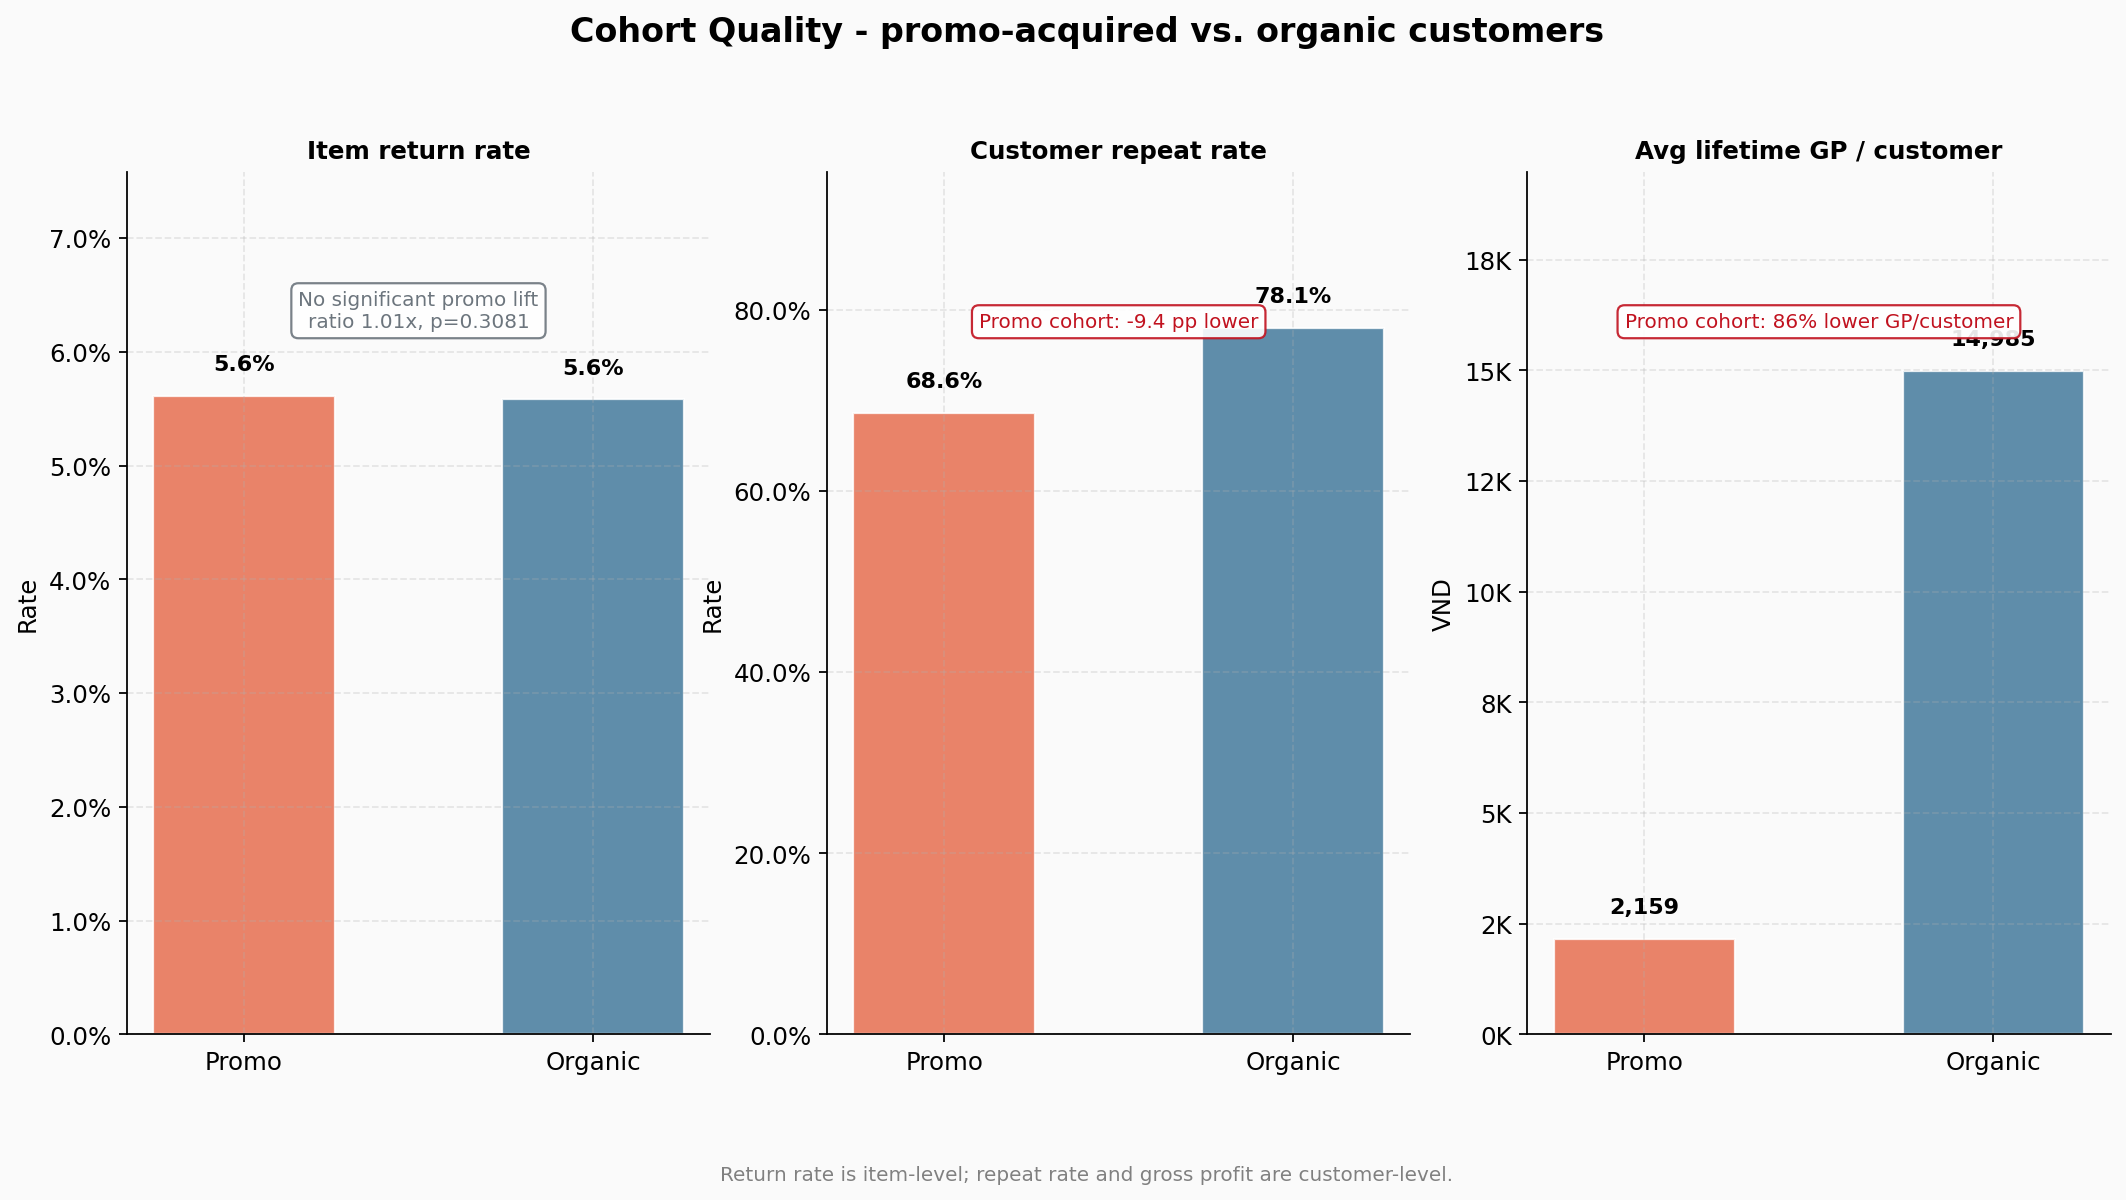

In [7]:
display(Image(str(CHARTS / "chart4_cohort_quality.png"), width=950))


In [8]:
triage = pd.read_csv(TABLES / "promo_triage_table.csv")
cohort = pd.read_csv(TABLES / "cohort_quality_table.csv")
cf = pd.read_csv(TABLES / "promo_counterfactual_proxy_table.csv")
promo_period = pd.read_csv(TABLES / "promo_covid_period_summary.csv")

print(f"Tỷ lệ chương trình có đóng góp lợi nhuận gộp âm: {(triage['total_net_contribution'] < 0).mean() * 100:.1f}%")
print(f"Gap GP so với matched organic margin proxy: {cf['gp_gap_vs_matched_organic_margin'].sum():,.0f} VND")

promo_period_display = promo_period.assign(
    period=promo_period["period"].replace(PERIOD_LABELS),
    negative_gp_rate=promo_period["negative_gp_rate"].map(lambda x: f"{x:.1%}"),
    gross_margin=promo_period["gross_margin"].map(lambda x: f"{x:.1%}"),
).rename(columns={
    "period": "giai_doan",
    "promotions": "so_chuong_trinh",
    "negative_gp_promotions": "so_chuong_trinh_gp_am",
    "negative_gp_rate": "ty_le_gp_am",
    "gp_contribution": "dong_gop_loi_nhuan_gop",
    "net_revenue": "doanh_thu_thuan",
    "gross_margin": "bien_loi_nhuan_gop",
    "gp_gap_vs_matched_organic_margin": "chenh_lech_gp_vs_benchmark",
    "rows": "so_dong",
})
display(promo_period_display)

cohort_display = cohort.copy()
cohort_display["metric"] = cohort_display["metric"].replace({
    "item_return_rate": "ty_le_tra_hang",
    "customer_repeat_rate": "ty_le_mua_lai",
    "avg_lifetime_gp_per_customer": "loi_nhuan_gop_vong_doi_moi_khach",
})
cohort_display = cohort_display.rename(columns={
    "metric": "chi_so",
    "promo": "nhom_khuyen_mai",
    "organic": "nhom_tu_nhien",
    "difference": "chenh_lech",
})
display(cohort_display)
cf_display = cf.head(10).rename(columns={
    "promo_id": "ma_khuyen_mai",
    "promo_name": "ten_khuyen_mai",
    "actual_gp": "gp_thuc_te",
    "expected_gp_at_matched_organic_margin": "gp_neu_dat_bien_tu_nhien_cung_nganh_quy",
    "gp_gap_vs_matched_organic_margin": "chenh_lech_gp_vs_benchmark",
    "net_revenue": "doanh_thu_thuan",
    "matched_margin_coverage": "ty_le_match_nganh_quy",
    "actual_margin": "bien_thuc_te",
    "expected_margin": "bien_benchmark",
})
display(cf_display)

Tỷ lệ chương trình có đóng góp lợi nhuận gộp âm: 100.0%
Gap GP so với matched organic margin proxy: -1,633,470,867 VND


,giai_doan,so_chuong_trinh,so_chuong_trinh_gp_am,dong_gop_loi_nhuan_gop,doanh_thu_thuan,so_dong,ty_le_gp_am,bien_loi_nhuan_gop,chenh_lech_gp_vs_benchmark
0,Pre-COVID (2012-2019),36,36,-6.747039e+08,3.724855e+09,232156,100.0%,-18.1%,-1.313366e+09
1,COVID (2020-2021),10,10,-1.192657e+08,6.450232e+08,30210,100.0%,-18.5%,-2.223206e+08
2,Post-COVID (2022),4,4,-5.290995e+07,3.159520e+08,13950,100.0%,-16.7%,-9.778430e+07


,chi_so,nhom_khuyen_mai,nhom_tu_nhien,chenh_lech
0,ty_le_tra_hang,0.056157,0.055817,0.000341
1,ty_le_mua_lai,0.686391,0.780608,-0.094217
2,loi_nhuan_gop_vong_doi_moi_khach,2158.906127,14985.089993,-12826.183867


,ma_khuyen_mai,ten_khuyen_mai,gp_thuc_te,gp_neu_dat_bien_tu_nhien_cung_nganh_quy,chenh_lech_gp_vs_benchmark,doanh_thu_thuan,ty_le_match_nganh_quy,rows,bien_thuc_te,bien_benchmark
0,PROMO-0025,Urban Blowout 2017,-6.072388e+07,1.589479e+07,-7.661867e+07,9.211108e+07,1.0,5385,-0.659246,0.172561
1,PROMO-0015,Urban Blowout 2015,-5.570163e+07,1.321228e+07,-6.891391e+07,8.377084e+07,1.0,5072,-0.664929,0.157719
2,PROMO-0005,Urban Blowout 2013,-5.386512e+07,1.342605e+07,-6.729117e+07,8.091959e+07,1.0,4887,-0.665662,0.165918
3,PROMO-0028,Mid-Year Sale 2018,-3.028329e+07,2.495238e+07,-5.523568e+07,1.407959e+08,1.0,8146,-0.215086,0.177224
4,PROMO-0022,Mid-Year Sale 2017,-3.137092e+07,2.292224e+07,-5.429316e+07,1.348113e+08,1.0,7506,-0.232703,0.170032
5,PROMO-0014,Year-End Sale 2015,-3.443419e+07,1.969069e+07,-5.412488e+07,1.179487e+08,1.0,11451,-0.291942,0.166943
6,PROMO-0020,Year-End Sale 2016,-3.302635e+07,2.017361e+07,-5.319996e+07,1.167657e+08,1.0,10121,-0.282843,0.172770
7,PROMO-0010,Year-End Sale 2014,-3.105161e+07,1.965999e+07,-5.071160e+07,1.120569e+08,1.0,11345,-0.277106,0.175447
8,PROMO-0035,Urban Blowout 2019,-3.903958e+07,1.150260e+07,-5.054219e+07,6.179147e+07,1.0,3174,-0.631796,0.186152
9,PROMO-0018,Mid-Year Sale 2016,-2.818841e+07,1.963083e+07,-4.781924e+07,1.181318e+08,1.0,7089,-0.238618,0.166177


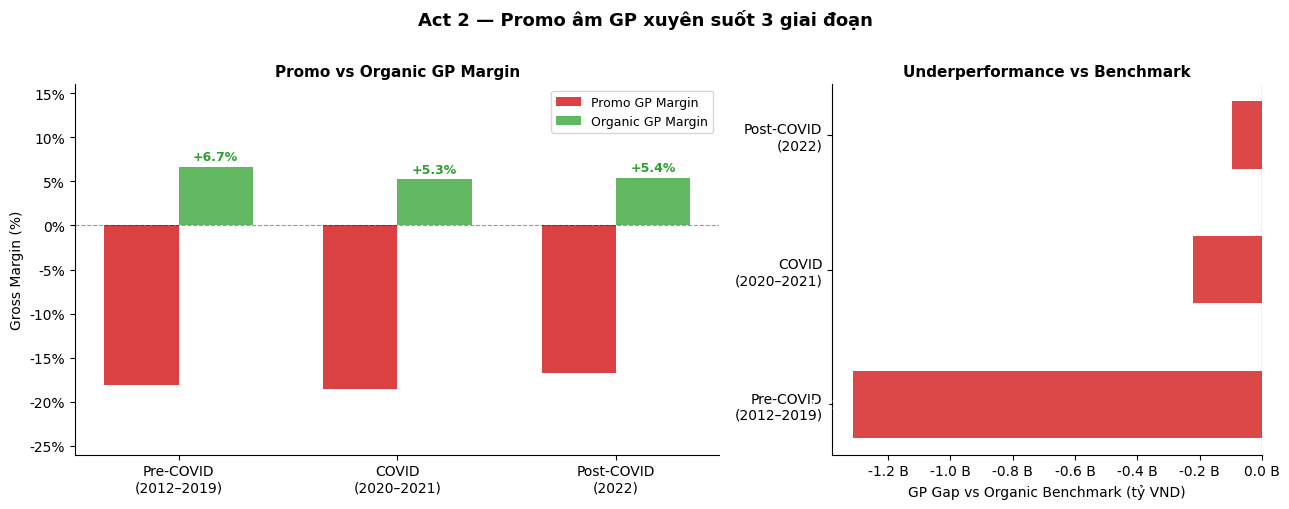

Saved: chart4b_promo_period_margin.png (132 KB)


In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"

PALETTE = {"red": "#d62728", "green": "#2ca02c", "orange": "#ff7f0e", "gray": "#7f7f7f"}

pp = pd.read_csv(TABLES / "promo_covid_period_summary.csv").set_index("period")
om = pd.read_csv(TABLES / "covid_period_margin_table.csv").set_index("period")

periods_key  = ["Pre-COVID", "COVID", "Post-COVID"]
period_lbls  = ["Pre-COVID\n(2012–2019)", "COVID\n(2020–2021)", "Post-COVID\n(2022)"]
promo_m      = [pp.loc[k, "gross_margin"] * 100 for k in periods_key]
organic_m    = [om.loc[k, "gross_margin"] * 100 for k in periods_key]
n_promos     = [int(pp.loc[k, "promotions"]) for k in periods_key]
gp_gap_b     = [pp.loc[k, "gp_gap_vs_matched_organic_margin"] / 1e9 for k in periods_key]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5),
                                gridspec_kw={"width_ratios": [3, 2]})
fig.suptitle("Act 2 — Promo âm GP xuyên suốt 3 giai đoạn", fontsize=13, fontweight="bold", y=1.01)

# ── Left: grouped bar — margin comparison ─────────────────────────────────────
x = np.arange(len(periods_key))
w = 0.34
b_p = ax1.bar(x - w/2, promo_m,   w, color=PALETTE["red"],   alpha=0.88, label="Promo GP Margin")
b_o = ax1.bar(x + w/2, organic_m, w, color=PALETTE["green"], alpha=0.75, label="Organic GP Margin")
ax1.axhline(0, color="black", lw=0.8, ls="--", alpha=0.4)
ax1.set_xticks(x); ax1.set_xticklabels(period_lbls, fontsize=10)
ax1.set_ylabel("Gross Margin (%)", fontsize=10)
ax1.set_ylim(-26, 16)
ax1.set_title("Promo vs Organic GP Margin", fontsize=11, fontweight="bold")
ax1.legend(fontsize=9, loc="upper right")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax1.spines[["top","right"]].set_visible(False)

for bar, n, m in zip(b_p, n_promos, promo_m):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.0,
             f"{n}/{n}\nâm", ha="center", va="top", fontsize=9, color="white", fontweight="bold")
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.2,
             f"{m:.1f}%", ha="center", va="top", fontsize=8.5, color="white")
for bar, m in zip(b_o, organic_m):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
             f"+{m:.1f}%", ha="center", va="bottom", fontsize=9, color=PALETTE["green"], fontweight="bold")

# ── Right: horizontal bar — GP gap vs benchmark ────────────────────────────────
y = np.arange(len(periods_key))
colors_gap = [PALETTE["red"]] * 3
h = ax2.barh(y, gp_gap_b, color=colors_gap, alpha=0.85, height=0.5)
ax2.set_yticks(y); ax2.set_yticklabels(period_lbls, fontsize=10)
ax2.set_xlabel("GP Gap vs Organic Benchmark (tỷ VND)", fontsize=10)
ax2.set_title("Underperformance vs Benchmark", fontsize=11, fontweight="bold")
ax2.axvline(0, color="black", lw=0.8)
ax2.spines[["top","right"]].set_visible(False)
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f B"))

for bar, val in zip(h, gp_gap_b):
    ax2.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}B", ha="right", va="center", fontsize=9, color="white", fontweight="bold")

plt.tight_layout()
out = CHARTS / "chart4b_promo_period_margin.png"
plt.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
sz = out.stat().st_size // 1024
print(f"Saved: {out.name} ({sz} KB)")


## Phân tích

**100% chương trình khuyến mãi có GP âm** sau hoàn tiền và phí vận chuyển. Pre-COVID chiếm **−1.31B VND** trong tổng gap **−1.63B VND** — lỗi cấu trúc có từ 2012, không phải COVID.

Tỷ lệ trả hàng: promo **5.6%** vs organic **5.6%** (Mann-Whitney p = 0.3081 — không có ý nghĩa thống kê). Bằng chứng chính:

| Chỉ số | Promo | Organic | Delta |
|--------|-------|---------|-------|
| Tỷ lệ mua lại | 68.6% | 78.1% | −9.5pp |
| GP vòng đời/khách | 2,159 VND | 14,985 VND | −86% |

**Kết luận Act 2:** 

Pre-COVID: Tác hại của khuyến mãi trong dữ liệu hiện tại chủ yếu đến từ biên lợi nhuận bị nén và hiệu quả kinh tế khách hàng yếu, không phải từ hành vi trả hàng. Vậy nên đây là lỗi thiết kế cấu trúc Promo.

COVID (2020–2021): chi phí giữ chân hợp lý trong khủng hoảng, đây là điều cần thiết trong tình trạng suy thoái kinh tế.

Post-COVID (2022): không còn lý do ngoại lệ, các promo cần cắt và thiết kế lại.

# Act 3 - Mô phỏng kịch bản nếu cắt khuyến mãi âm

**Câu hỏi trung tâm:** Nếu cắt các chương trình có đóng góp lợi nhuận gộp âm, kết quả tài chính thay đổi thế nào dưới các giả định nhu cầu quay lại khác nhau?

Dự báo tuyến tính chỉ đóng vai trò cảnh báo rủi ro; phần quyết định chính là mô phỏng kịch bản tài chính khi cắt các chương trình âm lợi nhuận.


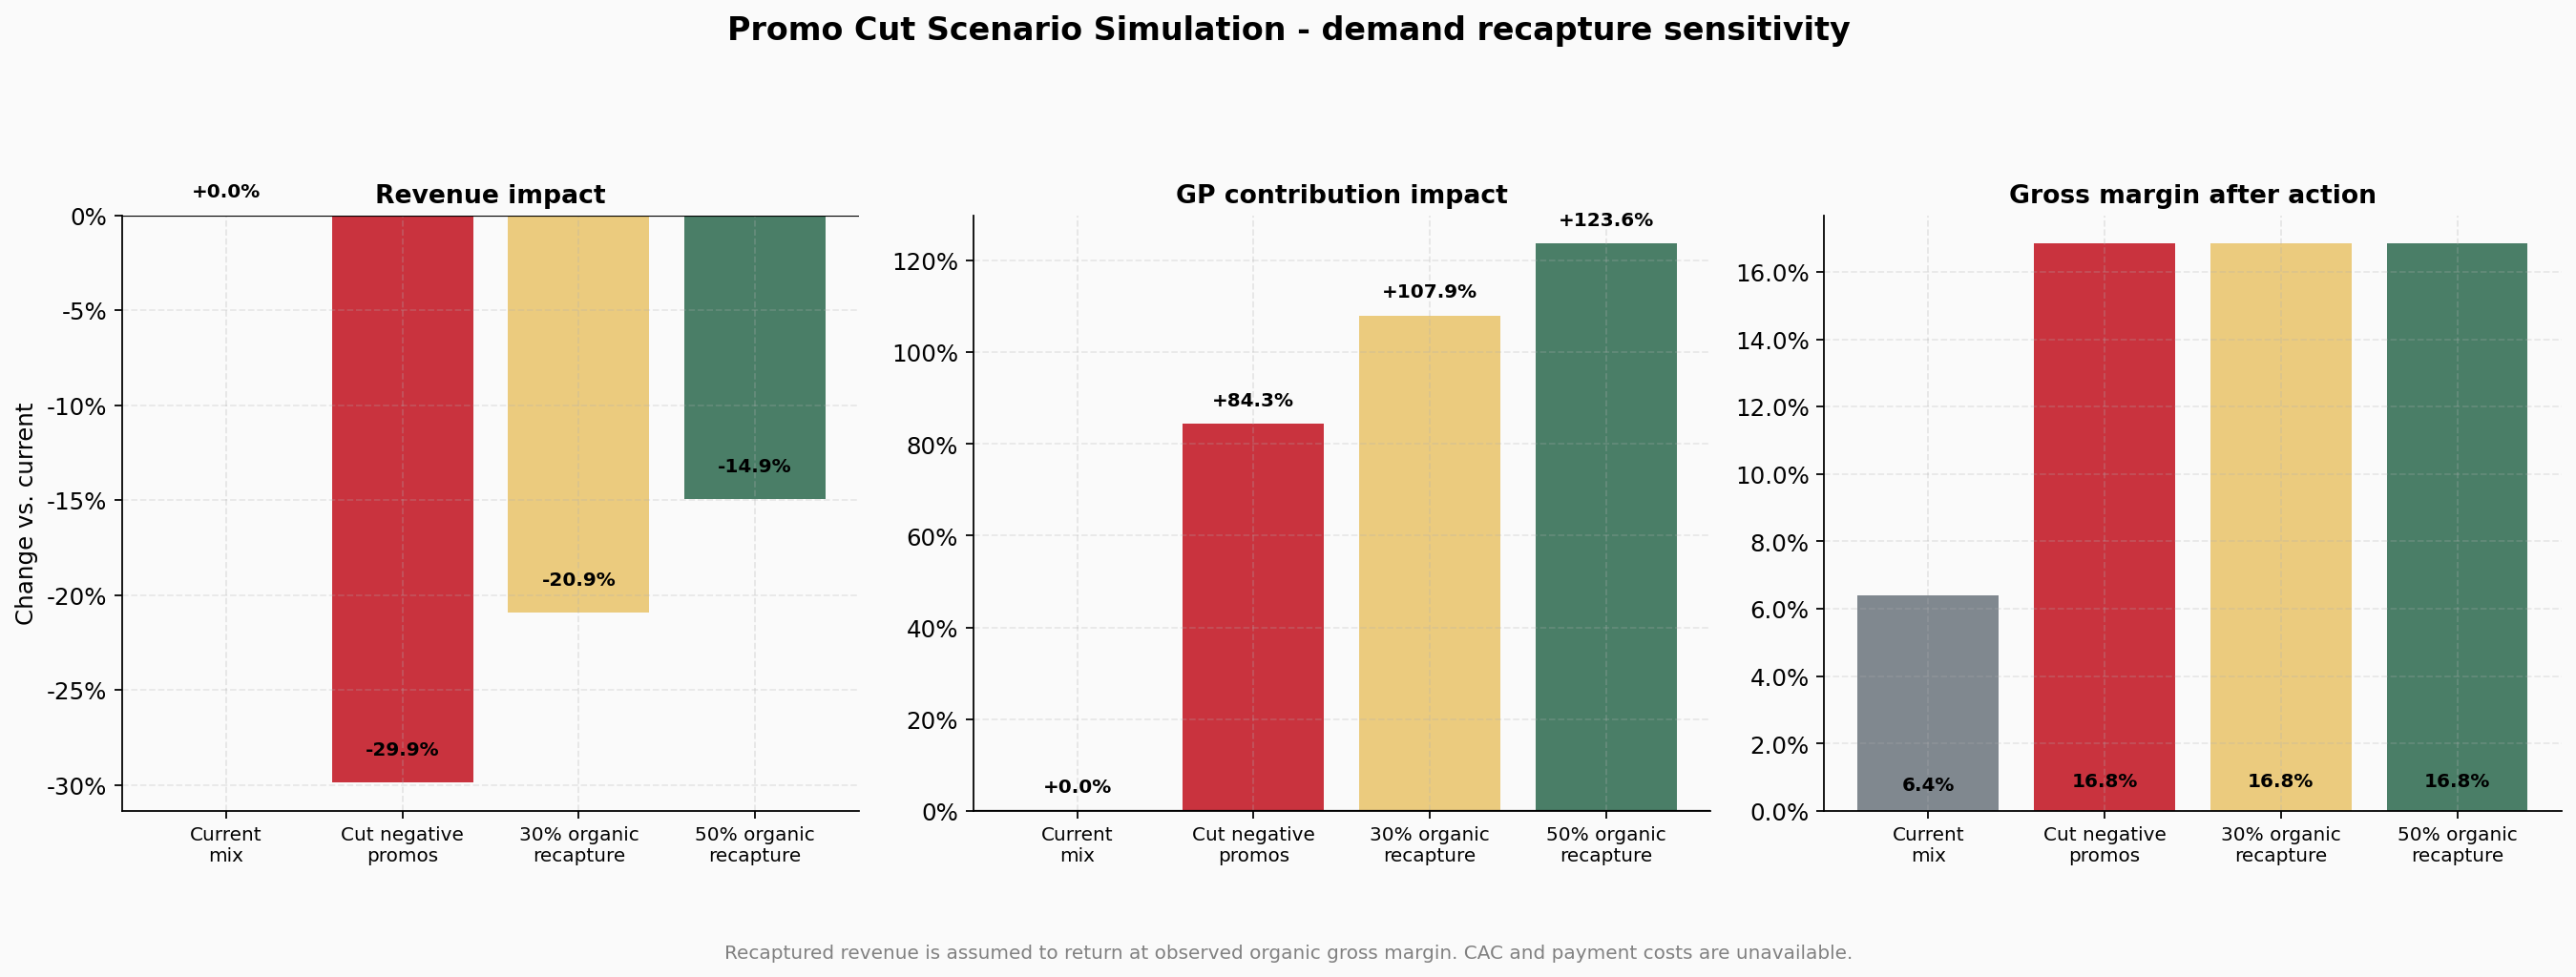

In [10]:
display(Image(str(CHARTS / "chart5_margin_scenario_simulation.png"), width=950))


In [11]:
scenario = pd.read_csv(TABLES / "promo_cut_scenario_table.csv")
scenario_display = scenario.copy()
scenario_display["assumption"] = scenario_display["assumption"].replace({
    "All promotions continue": "Giữ nguyên toàn bộ khuyến mãi",
    "0% of removed promo revenue returns at organic margin": "0% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
    "30% of removed promo revenue returns at organic margin": "30% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
    "50% of removed promo revenue returns at organic margin": "50% doanh thu khuyến mãi bị cắt quay lại ở biên tự nhiên",
})
scenario_display = scenario_display.rename(columns={
    "scope": "pham_vi",
    "scenario": "kich_ban",
    "recapture_rate": "ty_le_nhu_cau_quay_lai",
    "revenue": "doanh_thu",
    "gp_contribution": "dong_gop_loi_nhuan_gop",
    "gross_margin": "bien_loi_nhuan_gop",
    "revenue_impact_pct": "tac_dong_doanh_thu_pct",
    "gp_impact_pct": "tac_dong_loi_nhuan_gop_pct",
    "assumption": "gia_dinh",
    "cut_promo_count": "so_promo_bi_cat",
    "organic_margin": "bien_tu_nhien",
})
display(scenario_display)

scenario_by_period = pd.read_csv(TABLES / "promo_cut_scenario_by_period_table.csv")
scenario_by_period_display = scenario_by_period[
    scenario_by_period["scenario"].isin(["Current mix", "Cut negative promos"])
].copy()
scenario_by_period_display["gross_margin"] = scenario_by_period_display["gross_margin"].map(lambda x: f"{x:.1%}")
scenario_by_period_display = scenario_by_period_display.rename(columns={
    "scope": "pham_vi",
    "scenario": "kich_ban",
    "revenue": "doanh_thu",
    "gp_contribution": "dong_gop_loi_nhuan_gop",
    "gross_margin": "bien_loi_nhuan_gop",
    "revenue_impact_pct": "tac_dong_doanh_thu_pct",
    "gp_impact_pct": "tac_dong_loi_nhuan_gop_pct",
    "cut_promo_count": "so_promo_bi_cat",
})
display(scenario_by_period_display[[
    "pham_vi", "kich_ban", "so_promo_bi_cat", "doanh_thu", "dong_gop_loi_nhuan_gop",
    "bien_loi_nhuan_gop", "tac_dong_doanh_thu_pct", "tac_dong_loi_nhuan_gop_pct"
]])

forecast = pd.read_csv(TABLES / "margin_forecast_table.csv")
forecast_display = forecast[forecast["quarter"].isin(["2026Q4", "2027Q4"])].rename(columns={
    "quarter": "quy",
    "date": "ngay",
    "forecast": "du_bao",
    "lower_1sd": "can_duoi_1sd",
    "upper_1sd": "can_tren_1sd",
})
display(forecast_display)

,pham_vi,kich_ban,ty_le_nhu_cau_quay_lai,doanh_thu,dong_gop_loi_nhuan_gop,bien_loi_nhuan_gop,tac_dong_doanh_thu_pct,tac_dong_loi_nhuan_gop_pct,gia_dinh,so_promo_bi_cat,bien_tu_nhien
0,Full history 2012-2022,Current mix,NaN,1.568087e+10,1.004011e+09,0.064028,0.000000,0.000000,Giữ nguyên toàn bộ khuyến mãi,50,0.168339
1,Full history 2012-2022,Cut negative promos,0.0,1.099504e+10,1.850890e+09,0.168339,-29.882465,84.349626,0% doanh thu khuyến mãi bị cắt quay lại ở biên...,50,0.168339
2,Full history 2012-2022,Cut + 30% organic recapture,0.3,1.240079e+10,2.087532e+09,0.168339,-20.917725,107.919284,30% doanh thu khuyến mãi bị cắt quay lại ở biê...,50,0.168339
3,Full history 2012-2022,Cut + 50% organic recapture,0.5,1.333795e+10,2.245294e+09,0.168339,-14.941232,123.632390,50% doanh thu khuyến mãi bị cắt quay lại ở biê...,50,0.168339


,pham_vi,kich_ban,so_promo_bi_cat,doanh_thu,dong_gop_loi_nhuan_gop,bien_loi_nhuan_gop,tac_dong_doanh_thu_pct,tac_dong_loi_nhuan_gop_pct
0,Full history 2012-2022,Current mix,50,1.568087e+10,1.004011e+09,6.4%,0.000000,0.000000
1,Full history 2012-2022,Cut negative promos,50,1.099504e+10,1.850890e+09,16.8%,-29.882465,84.349626
4,Post-COVID normalized 2022,Current mix,5,1.115307e+09,6.014628e+07,5.4%,0.000000,0.000000
5,Post-COVID normalized 2022,Cut negative promos,5,7.956266e+08,1.143036e+08,14.4%,-28.663004,90.042651


,quy,ngay,du_bao,can_duoi_1sd,can_tren_1sd
15,2026Q4,2026-10-01,-0.129175,-8.979894,8.721543
19,2027Q4,2027-10-01,-0.691601,-9.542319,8.159118


## Phân tích

Hiện trạng toàn lịch sử: **15,681B VND doanh thu** — **1,004B VND GP** — biên **6.4%**.

| Kịch bản | Doanh thu | GP | Biên |
|---|---|---|---|
| Giữ nguyên | 15,681B | 1,004B | 6.4% |
| Cắt 50 promo (0% recapture) | 10,995B (−29.9%) | 1,851B (+84.3%) | 16.8% |
| Cắt + 30% recapture | 12,401B (−20.9%) | 2,088B (+107.9%) | 16.8% |
| Cắt + 50% recapture | 13,338B (−14.9%) | 2,245B (+123.6%) | 16.8% |

Kiểm định **Post-COVID 2022** (cắt 5 promo âm): doanh thu **−28.7%**, GP **+90.0%** — nhất quán khi loại toàn bộ lịch sử 2012–2021.

Dự báo tuyến tính: xu hướng **−0.1pp/quý**, Q4/2026 = **−0.1%** (khoảng −9.0% đến +8.7%) — khoảng quá rộng để ra quyết định; chỉ dùng làm cảnh báo rủi ro.

**Kết luận Act 3:** Pause promo âm cải thiện GP trong mọi kịch bản kể cả 0% recapture. Triển khai thực tế vẫn cần redesign + A/B holdout.


# Act 4 - Khuyến mãi chạy vào vùng rủi ro tồn kho

**Câu hỏi trung tâm:** Khuyến mãi có đang được kích hoạt trong giai đoạn ngành hàng có mức sẵn sàng tồn kho yếu không?

Phân tích tập trung vào giao điểm giữa lịch khuyến mãi và tồn kho yếu ở cấp chương trình x ngành hàng x tháng.


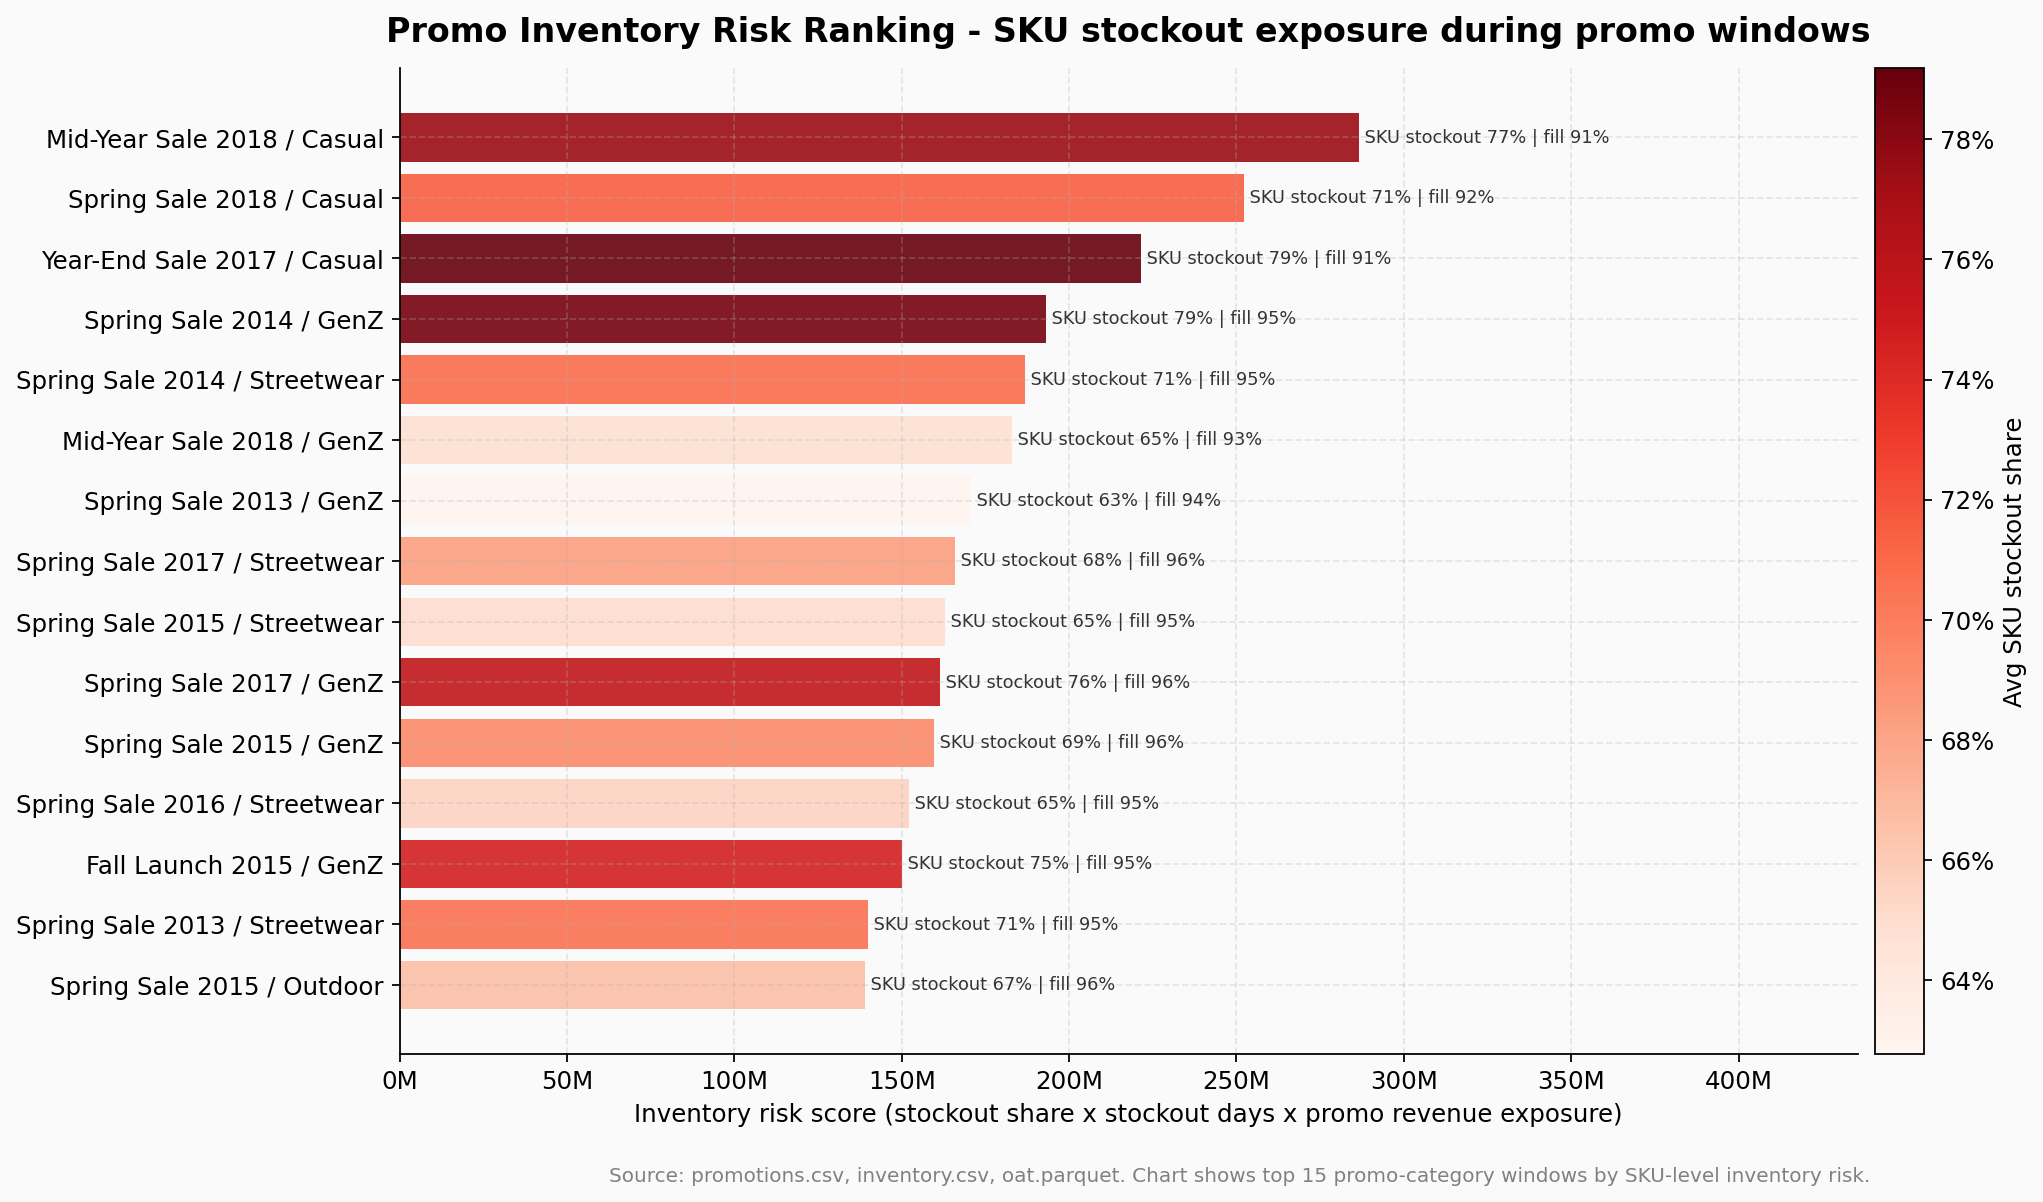

In [12]:
display(Image(str(CHARTS / "chart6_promo_inventory_risk.png"), width=950))


In [13]:
overlaps = pd.read_csv(TABLES / "promo_stockout_overlaps.csv")
risk = pd.read_csv(TABLES / "promo_inventory_risk_table.csv")
stockout_period = pd.read_csv(TABLES / "stockout_covid_period_summary.csv")
stockout_year = pd.read_csv(TABLES / "stockout_yearly_summary.csv")

print(f"Số event chồng lấn: {len(overlaps)}")
print(f"Số chương trình bị ảnh hưởng: {overlaps['promo_id'].nunique()}")
print(f"Ngành hàng bị ảnh hưởng: {sorted(overlaps['category'].unique().tolist())}")
print(f"Tỷ lệ SKU thiếu hàng trung bình: {overlaps['stockout_product_share'].mean():.1%}")
print(f"Tỷ lệ đáp ứng đơn trung bình: {overlaps['avg_fill_rate'].mean():.1%}")
print(f"Lợi nhuận gộp ước tính bị mất: {overlaps['estimated_lost_gp'].sum():,.0f} VND")

stockout_period_display = stockout_period.assign(
    period=stockout_period["period"].replace(PERIOD_LABELS),
    stockout_product_share=stockout_period["stockout_product_share"].map(lambda x: f"{x:.1%}"),
    avg_fill_rate=stockout_period["avg_fill_rate"].map(lambda x: f"{x:.1%}"),
).rename(columns={
    "period": "giai_doan",
    "stockout_product_share": "ty_le_sku_thieu_hang",
    "avg_stockout_days": "so_ngay_thieu_hang_tb",
    "avg_fill_rate": "ty_le_dap_ung_don_tb",
    "rows": "so_dong_ton_kho",
})
display(stockout_period_display)

yearly_display = stockout_year.assign(
    stockout_product_share=stockout_year["stockout_product_share"].map(lambda x: f"{x:.1%}"),
    avg_fill_rate=stockout_year["avg_fill_rate"].map(lambda x: f"{x:.1%}"),
).rename(columns={
    "year": "nam",
    "period": "giai_doan",
    "stockout_product_share": "ty_le_sku_thieu_hang",
    "avg_stockout_days": "so_ngay_thieu_hang_tb",
    "avg_fill_rate": "ty_le_dap_ung_don_tb",
})
display(yearly_display)

risk_display = risk.head(20).rename(columns={
    "promo_id": "ma_khuyen_mai",
    "promo_name": "ten_khuyen_mai",
    "category": "nganh_hang",
    "overlap_months": "so_thang_chong_lan",
    "avg_sku_stockout_share": "ty_le_sku_thieu_hang_tb",
    "avg_fill_rate": "ty_le_dap_ung_don_tb",
    "estimated_lost_gp": "loi_nhuan_gop_uoc_tinh_mat",
    "promo_gp_contribution": "dong_gop_loi_nhuan_gop",
    "promo_net_revenue": "doanh_thu_thuan_khuyen_mai",
    "inventory_risk_score": "diem_rui_ro_ton_kho",
})
display(risk_display)

Số event chồng lấn: 426
Số chương trình bị ảnh hưởng: 50
Ngành hàng bị ảnh hưởng: ['Casual', 'GenZ', 'Outdoor', 'Streetwear']
Tỷ lệ SKU thiếu hàng trung bình: 67.5%
Tỷ lệ đáp ứng đơn trung bình: 96.2%
Lợi nhuận gộp ước tính bị mất: 23,547,465 VND


,giai_doan,ty_le_sku_thieu_hang,so_ngay_thieu_hang_tb,ty_le_dap_ung_don_tb,so_dong_ton_kho
0,Pre-COVID (2012-2019),67.5%,1.187672,96.0%,43720
1,COVID (2020-2021),67.1%,1.086853,96.4%,11295
2,Post-COVID (2022),66.7%,1.094037,96.4%,5232


,nam,ty_le_sku_thieu_hang,so_ngay_thieu_hang_tb,ty_le_dap_ung_don_tb,giai_doan
0,2012,68.2%,1.385979,95.4%,Pre-COVID
1,2013,67.8%,1.262478,95.8%,Pre-COVID
2,2014,67.6%,1.202696,96.0%,Pre-COVID
3,2015,67.5%,1.202486,96.0%,Pre-COVID
4,2016,67.9%,1.187447,96.0%,Pre-COVID
5,2017,67.8%,1.187048,96.0%,Pre-COVID
6,2018,66.5%,1.119391,96.3%,Pre-COVID
7,2019,66.9%,1.072494,96.4%,Pre-COVID
8,2020,66.7%,1.032888,96.6%,COVID
9,2021,67.5%,1.141558,96.2%,COVID


,ma_khuyen_mai,ten_khuyen_mai,nganh_hang,so_thang_chong_lan,ty_le_sku_thieu_hang_tb,max_sku_stockout_share,avg_stockout_days,max_stockout_days,ty_le_dap_ung_don_tb,min_fill_rate,loi_nhuan_gop_uoc_tinh_mat,dong_gop_loi_nhuan_gop,doanh_thu_thuan_khuyen_mai,negative_gp_exposure,diem_rui_ro_ton_kho
0,PROMO-0028,Mid-Year Sale 2018,Casual,2,0.774194,0.870968,2.629032,22,0.912366,0.2667,7.932671e+04,-3.028329e+07,1.407959e+08,3.028329e+07,2.865731e+08
1,PROMO-0027,Spring Sale 2018,Casual,2,0.714683,0.774194,2.369855,18,0.921008,0.4000,2.473240e+04,-8.596910e+06,1.489566e+08,8.596910e+06,2.522871e+08
2,PROMO-0024,Year-End Sale 2017,Casual,3,0.791795,0.846154,2.805128,19,0.906494,0.3667,3.386859e+04,-2.743982e+07,9.974252e+07,2.743982e+07,2.215367e+08
3,PROMO-0007,Spring Sale 2014,GenZ,2,0.786718,0.814815,1.508940,10,0.949701,0.6667,1.159950e+04,-1.246593e+07,1.626504e+08,1.246593e+07,1.930839e+08
4,PROMO-0007,Spring Sale 2014,Streetwear,2,0.708615,0.731183,1.620530,28,0.945981,0.0667,5.748829e+05,-1.246593e+07,1.626504e+08,1.246593e+07,1.867765e+08
5,PROMO-0028,Mid-Year Sale 2018,GenZ,2,0.647969,0.659574,2.003868,17,0.933203,0.4333,1.000183e+05,-3.028329e+07,1.407959e+08,3.028329e+07,1.828157e+08
6,PROMO-0001,Spring Sale 2013,GenZ,2,0.627706,0.636364,1.906926,23,0.936437,0.2333,1.284082e+04,-8.785409e+06,1.426156e+08,8.785409e+06,1.707092e+08
7,PROMO-0021,Spring Sale 2017,Streetwear,2,0.683382,0.728302,1.349492,22,0.955017,0.2667,4.351671e+05,-1.211826e+07,1.797860e+08,1.211826e+07,1.658019e+08
8,PROMO-0011,Spring Sale 2015,Streetwear,2,0.650025,0.699275,1.421343,25,0.952622,0.1667,5.584992e+05,-1.035161e+07,1.762220e+08,1.035161e+07,1.628130e+08
9,PROMO-0021,Spring Sale 2017,GenZ,2,0.756536,0.777778,1.186275,2,0.960454,0.9333,4.740742e+03,-1.211826e+07,1.797860e+08,1.211826e+07,1.613507e+08


## Phân tích

**426 điểm chồng lấn** (promo × ngành hàng × tháng), toàn bộ **50 chương trình** bị ảnh hưởng. Tỷ lệ đáp ứng đơn **96.2%** — không phải thất bại toàn ngành. Rủi ro nằm ở cấp SKU: **67.5% SKU thiếu hàng** trong các tháng chồng lấn.

Stockout **không tăng trong COVID**: Pre/COVID/Post = **67.5% / 67.1% / 66.7%** — đây là rủi ro vận hành cấu trúc, không phải COVID supply shock.

Cặp rủi ro cao nhất: **Mid-Year Sale 2018 / Casual** (risk score 286.6M VND). GP ước tính mất: **23.5M VND** — đọc như proxy bảo thủ cho ưu tiên điều tra SKU/nhà cung ứng.

**Kết luận Act 4:** Cần cổng kiểm tra tồn kho trước khi kích hoạt promo. Nguyên nhân thiếu hàng cần điều tra thêm ở cấp SKU/nhà cung ứng.


# Act 5 - Kê đơn hành động cho từng chương trình

**Câu hỏi trung tâm:** Dựa trên hiệu quả tài chính, chất lượng khách hàng và rủi ro tồn kho, chương trình nào nên KEEP, CUT hoặc RESCHEDULE?

Phần cuối chuyển toàn bộ kết quả phân tích thành quyết định cụ thể cho từng chương trình.


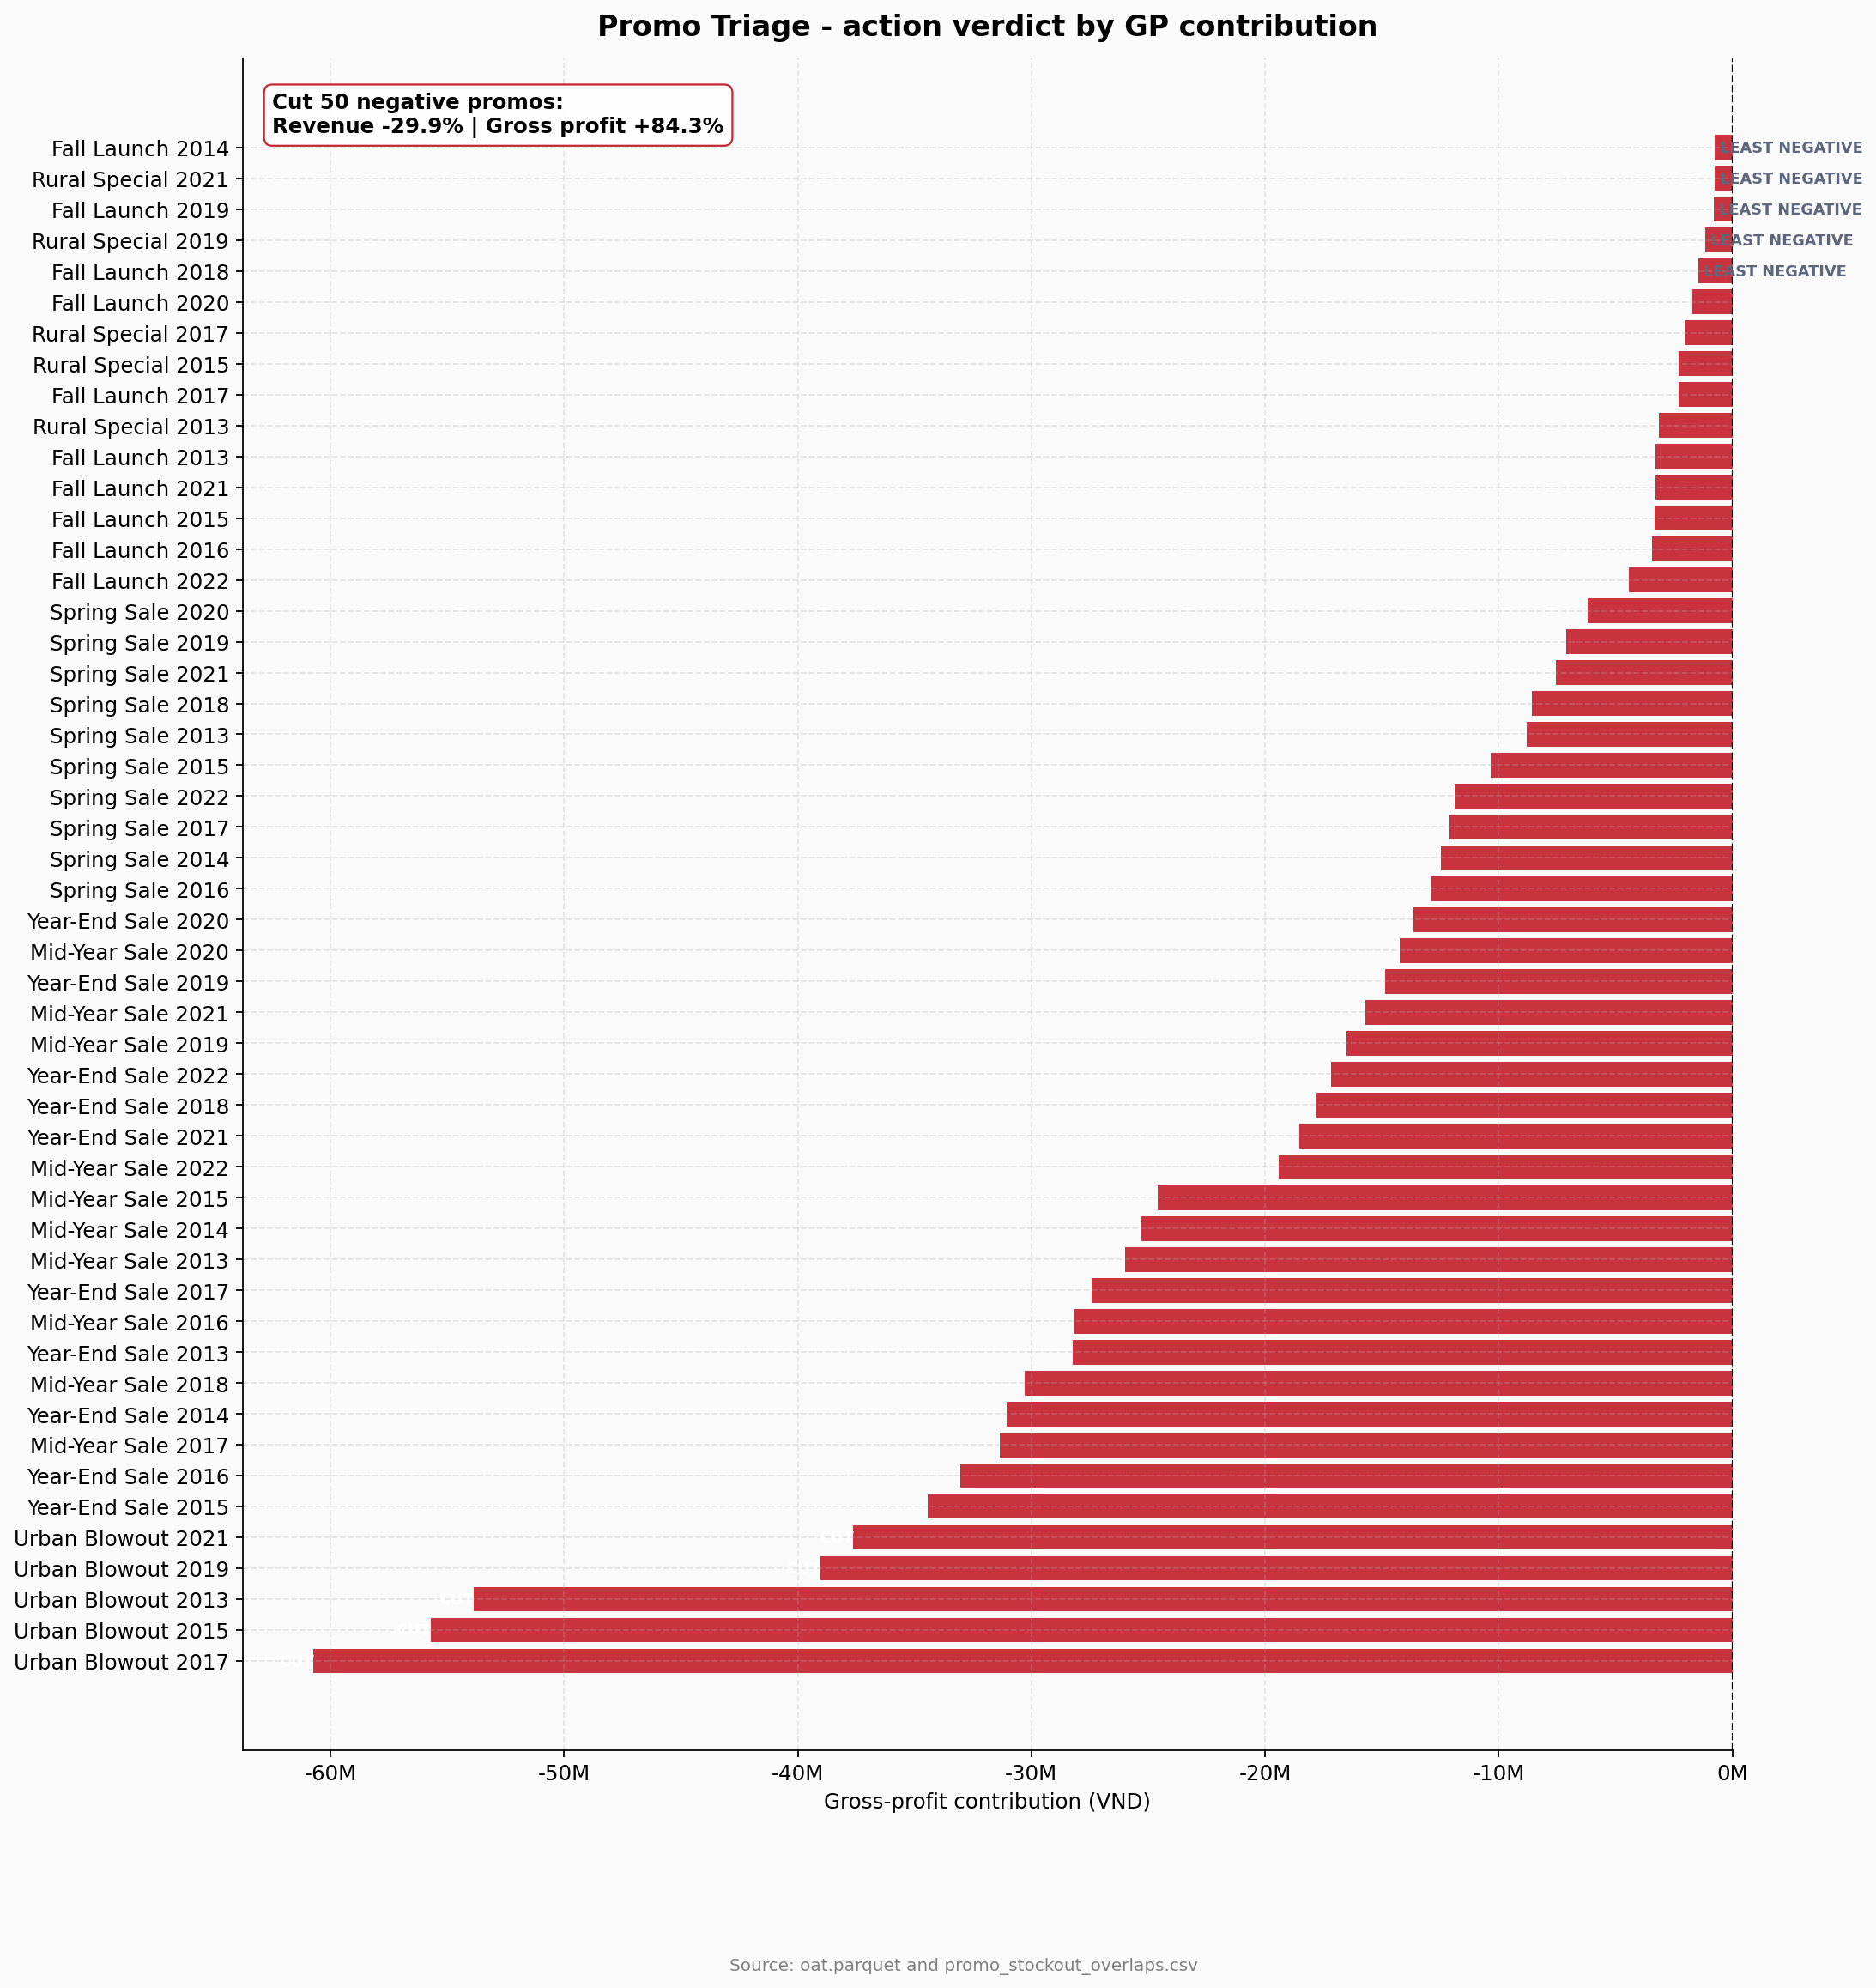

In [14]:
display(Image(str(CHARTS / "chart7_promo_triage.png"), width=950))


In [15]:
triage = pd.read_csv(TABLES / "promo_triage_table.csv")
summary = triage.groupby("verdict").agg(
    count=("promo_id", "count"),
    total_net_contribution=("total_net_contribution", "sum"),
    estimated_annual_impact_vnd=("estimated_annual_impact_vnd", "sum"),
).reset_index()
summary_display = summary.rename(columns={
    "verdict": "quyet_dinh",
    "count": "so_chuong_trinh",
    "total_net_contribution": "tong_dong_gop_loi_nhuan_gop",
    "estimated_annual_impact_vnd": "tac_dong_uoc_tinh_nam_vnd",
})
display(summary_display)
print("Các chương trình CUT ít âm nhất")
cols = ["promo_name", "total_net_contribution", "return_rate", "stockout_overlap"]
display(triage[triage.verdict == "CUT"].nlargest(5, "total_net_contribution")[cols].rename(columns={
    "promo_name": "ten_khuyen_mai",
    "total_net_contribution": "dong_gop_loi_nhuan_gop",
    "return_rate": "ty_le_tra_hang",
    "stockout_overlap": "chong_lan_thieu_hang",
}))
print("Các chương trình CUT âm nặng nhất")
display(triage[triage.verdict == "CUT"].nsmallest(5, "total_net_contribution")[cols].rename(columns={
    "promo_name": "ten_khuyen_mai",
    "total_net_contribution": "dong_gop_loi_nhuan_gop",
    "return_rate": "ty_le_tra_hang",
    "stockout_overlap": "chong_lan_thieu_hang",
}))


,quyet_dinh,so_chuong_trinh,tong_dong_gop_loi_nhuan_gop,tac_dong_uoc_tinh_nam_vnd
0,CUT,50,-8.468795e+08,8.468795e+08


Các chương trình CUT ít âm nhất


,ten_khuyen_mai,dong_gop_loi_nhuan_gop,ty_le_tra_hang,chong_lan_thieu_hang
0,Fall Launch 2014,-7.769355e+05,0.056413,Yes
1,Rural Special 2021,-7.771840e+05,0.064626,Yes
2,Fall Launch 2019,-7.811778e+05,0.059013,Yes
3,Rural Special 2019,-1.151314e+06,0.054529,Yes
4,Fall Launch 2018,-1.454776e+06,0.055915,Yes


Các chương trình CUT âm nặng nhất


,ten_khuyen_mai,dong_gop_loi_nhuan_gop,ty_le_tra_hang,chong_lan_thieu_hang
49,Urban Blowout 2017,-6.072388e+07,0.058682,Yes
48,Urban Blowout 2015,-5.570163e+07,0.056979,Yes
47,Urban Blowout 2013,-5.386512e+07,0.052589,Yes
46,Urban Blowout 2019,-3.903958e+07,0.055451,Yes
45,Urban Blowout 2021,-3.762514e+07,0.057155,Yes


## Phân tích

Triage: **0 KEEP / 50 CUT**, tổng GP âm **−846.9M VND**.

Không phải "cấm khuyến mãi" — mà là **không lặp lại 50 mẫu cũ dưới cùng cơ chế giá/chiết khấu/tồn kho**. Chương trình mới chỉ triển khai sau khi reprice/redesign đạt GP dự kiến dương.

Đánh đổi (0% recapture): doanh thu **−29.9%**, GP **+84.3%**. Với 30% recapture: doanh thu **−20.9%**, GP **+107.9%**.

**Kết luận Act 5:** Loại 50 mẫu cũ. Cổng duyệt mới kiểm tra 3 điều kiện: (1) GP contribution dự kiến > 0, (2) repeat rate không thấp hơn organic, (3) SKU stockout dưới ngưỡng an toàn.


---
## Tóm tắt điều hành

1. Chất lượng doanh thu đang xấu đi: **749,607,320 VND** rò rỉ qua chiết khấu, **510,598,507 VND** qua hoàn tiền, biên lợi nhuận giảm từ **17.6%** xuống **5.4%**. Sau khi tách kỳ: **6.7% Pre-COVID**, **5.3% COVID**, **5.4% Post-COVID** — baseline đã mỏng từ trước đại dịch.

2. Promo âm GP là vấn đề cấu trúc, không phải artifact COVID: **36/36 promo (2012–2019)** đều âm, chiếm **-1.31B VND** trong tổng gap **-1.63B VND**. COVID (2020–2021) là ngoại lệ hợp lý — promo duy trì khách hàng trong khủng hoảng kinh tế. Post-COVID (2022), **4/4 promo vẫn âm** mà không còn lý do ngoại lệ: đây là cửa sổ hành động.

3. Stress test xác nhận quyết định pause/redesign có sức chống chịu: toàn lịch sử cho **doanh thu -29.9% / GP contribution +84.3%** trong kịch bản 0% recapture. Khi chỉ dùng **Post-COVID 2022**, kết quả vẫn là **doanh thu -28.7% / GP contribution +90.0%**.

4. Chồng lấn giữa khuyến mãi và thiếu hàng tồn tại ở cấp SKU: **426 điểm chồng lấn**, **67.5% tỷ lệ SKU thiếu hàng**. Stockout không tăng trong COVID (**Pre/COVID/Post: 67.5% / 67.1% / 66.7%**) — đây là rủi ro vận hành mang tính cấu trúc, không phải cú sốc dịch bệnh.

5. Hành động: **không lặp lại 50 mẫu promo lịch sử như hiện tại**. Thiết kế lại cổng duyệt promo theo GP contribution dự kiến và mức sẵn sàng tồn kho.

## Ba khuyến nghị hành động

| Ưu tiên | Hành động | Tác động ước tính |
|---|---|---|
| 1 | Cắt/pause các mẫu promo Pre-COVID và Post-COVID âm GP; tái thiết kế trước khi khôi phục | GP contribution +84.3% full history; +90.0% trong 2022-only stress test |
| 2 | Thiết kế lại cổng duyệt khuyến mãi theo GP contribution dự kiến sau hoàn tiền và phí vận chuyển | Không triển khai nếu GP contribution dự kiến ≤ 0 |
| 3 | Thêm cổng kiểm tra tồn kho trước khi triển khai khuyến mãi | Chặn hoặc reschedule promo khi tỷ lệ SKU thiếu hàng vượt ngưỡng an toàn |

## Giới hạn bằng chứng

- Đây là phép lọc theo đóng góp lợi nhuận gộp sau hoàn tiền và phí vận chuyển, chưa phải biên đóng góp đầy đủ vì dữ liệu không có chi phí thu hút khách hàng, chi phí xử lý thanh toán và chi phí vận hành cố định.
- Counterfactual proxy dùng biên lợi nhuận tự nhiên theo ngành hàng/quý để benchmark, nhưng chưa thay thế được causal uplift model, holdout test, hoặc A/B experiment.
- Phân tích đã tách **Pre-COVID (2012-2019)**, **COVID (2020-2021)** và **Post-COVID (2022)**. COVID có thể ảnh hưởng demand và hành vi mua hàng theo cách dữ liệu hiện tại chưa đo trực tiếp — nhưng Pre-COVID baseline đủ mạnh để bác phản biện "100% âm là do đại dịch".
- Phân tích khuyến mãi dùng `discount_amount` thực tế trong `order_items` vì cột này khớp với `payments.payment_value`; các cột `promo_channel` và `min_order_value` trong bảng master được dùng như metadata.
- Tác động doanh thu **-29.9%** là kịch bản cơ học thận trọng nhất (0% recapture); kịch bản 2022-only là normalization đơn giản, không phải causal forecast.
- Dữ liệu inventory không xác nhận spike stockout trong COVID; kết luận về nguyên nhân thiếu hàng cần thêm dữ liệu lead time và purchase order.
